# *Do Accessible Steam Indie Games Get More Player Engagement?* — Data Analysis Notebook

**Author:** Palatine Rigaut

**Date:** May, 2026

## 1. Library Imports

In [300]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullLocator
import statsmodels.formula.api as smf
from matplotlib.patches import Patch

## 2. Visualization Setup

### 2.a. Project Paths

In [301]:
DATA_PATH = Path('Dataset.csv')

### 2.b. Color Constants

In [302]:
RED = '#991A25'
GREEN = '#1A994D'
BROWN = '#997333'
LINGUISTIC_BLUE = '#677FE9'
TECH_PURPLE = '#A067E9'
ECON_YELLOW = '#FFE45C'
BLUE_LIGHT = '#DCEBFF'
BLUE_MID = '#85B3FF'
BLUE_DARK = '#2F74E8'
BLACK = '#202020'
DARK_GREY = '#707070'
LIGHT_GREY = '#E6E6E6'
MID_GREY = '#B8B8B8'
SHADE_GREY = '#DADDE4'
WHITE = '#FFFFFF'

### 2.c. Color Palettes

In [303]:
review_cmap = LinearSegmentedColormap.from_list('review_red_brown_green', [RED, BROWN, GREEN])
blue_cmap = LinearSegmentedColormap.from_list('fresh_blue', [BLUE_LIGHT, BLUE_MID, BLUE_DARK])
grey_cmap = LinearSegmentedColormap.from_list('ink_grey', ['#F2F2F2', '#A8A8A8', BLACK])
purple_cmap = LinearSegmentedColormap.from_list('technical_purple', ['#EBDDFF', '#BB8EF4', TECH_PURPLE])
yellow_cmap = LinearSegmentedColormap.from_list('economic_yellow', ['#FFF7C2', ECON_YELLOW, '#D9B100'])

### 2.d. Figure Style

In [304]:
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9.2,
    'axes.labelsize': 10.2,
    'xtick.labelsize': 8.4,
    'ytick.labelsize': 8.4,
    'axes.labelcolor': BLACK,
    'xtick.color': BLACK,
    'ytick.color': BLACK,
})

## 3. Plot Helpers

### 3.a. Axis Cleanup

In [305]:
def _set_minor_locator(ax, axis, enabled=True):
    ticker = ax.xaxis if axis == 'x' else ax.yaxis
    scale = ax.get_xscale() if axis == 'x' else ax.get_yscale()
    if not enabled:
        ticker.set_minor_locator(NullLocator())
    elif scale == 'log':
        ticker.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    else:
        ticker.set_minor_locator(AutoMinorLocator())


def clean_axis(ax, minor_x=True, minor_y=True):
    ax.grid(False)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('#333333')
        ax.spines[spine].set_linewidth(0.85)
    _set_minor_locator(ax, 'x', minor_x)
    _set_minor_locator(ax, 'y', minor_y)
    ax.tick_params(axis='both', which='major', width=0.85, length=3.5, direction='out', pad=2)
    ax.tick_params(axis='both', which='minor', width=0.65, length=2, direction='out')


def format_log_x(ax, ticks, labels):
    ax.set_xscale('log')
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

def shaded_barh(ax, series, yes_color, total_n):
    labels = series.index.tolist()
    yes_vals = series.values.astype(float)
    y = np.arange(len(labels))
    ax.barh(y, total_n, color='white', edgecolor='#d9d9d9', hatch='....', linewidth=0, zorder=1)
    ax.barh(y, yes_vals, color=yes_color, edgecolor='none', zorder=2)
    for i, v in enumerate(yes_vals):
        ax.text(v - total_n * 0.02, i, f'{int(v)}', va='center', ha='right', fontsize=7, color='white', fontweight='bold', zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.legend(
    handles=[
        Patch(facecolor=yes_color, edgecolor='none', label='Yes'),
        Patch(facecolor='white', edgecolor='#d9d9d9', hatch='....', label='No')
    ],
    loc='center left',
    bbox_to_anchor=(1.01, 0.05),
    frameon=False,
    fontsize=7)

### 3.b. Panel Labels

In [306]:
def panel_label(ax, label):
    ax.set_title(label, fontsize=13, fontweight='bold', pad=7)


def show_figure(fig):
    plt.show()
    plt.close(fig)

### 3.c. Bar Helpers

In [307]:
def gradient_hist(ax, values, bins, cmap, norm=None):
    x = pd.Series(values).dropna().to_numpy()
    counts, edges = np.histogram(x, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    norm = norm or Normalize(centers.min(), centers.max())
    ax.bar(edges[:-1], counts, width=np.diff(edges) * 0.82, align='edge', color=cmap(norm(centers)), edgecolor=WHITE, linewidth=0.7)


def log_gradient_hist(ax, values, bins, ticks, tick_labels, cmap):
    x = pd.Series(values).dropna()
    x = x[x > 0]
    counts, edges = np.histogram(x, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])
    colors = cmap(Normalize(np.log10(centers).min(), np.log10(centers).max())(np.log10(centers)))
    ax.bar(edges[:-1], counts, width=np.diff(edges) * 0.82, align='edge', color=colors, edgecolor=WHITE, linewidth=0.7)
    format_log_x(ax, ticks, tick_labels)


def binary_bar(ax, labels, counts, yes_index, yes_color):
    for i, (label, value) in enumerate(zip(labels, counts)):
        if i == yes_index:
            ax.bar(label, value, color=yes_color, width=0.54, edgecolor='none')
        else:
            ax.bar(label, value, color='none', width=0.54, edgecolor=SHADE_GREY, hatch='....', linewidth=0.0)
    ymax = max(counts) * 1.24
    ax.set_ylim(0, ymax)
    for i, value in enumerate(counts):
        ax.text(i, value + ymax * 0.025, f'{int(value)}', ha='center', va='bottom', fontsize=7.2, color=BLACK)


def count_bar(ax, labels, counts, colors):
    ax.bar(labels, counts, color=colors, width=0.54, edgecolor='none')
    ymax = max(counts) * 1.24
    ax.set_ylim(0, ymax)
    for i, value in enumerate(counts):
        ax.text(i, value + ymax * 0.025, f'{int(value)}', ha='center', va='bottom', fontsize=7.2, color=BLACK)

### 3.d. Review Tick Labels

In [308]:
def color_review_ticks(ax):
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0%\n(mostly not\nrecommended)', '50%', '100%\n(mostly\nrecommended)'])
    for tick, color in zip(ax.get_xticklabels(), [RED, BROWN, GREEN]):
        tick.set_color(color)
        tick.set_fontweight('bold')
        tick.set_fontsize(5.8)

## 4. Data Import

In [309]:
df = pd.read_csv(DATA_PATH)

if 'log_language_count' not in df.columns:
    df['log_language_count'] = np.log(df['language_count'])

continuous_predictors = [
    'positive_rate', 'game_age_years', 'log_price_paid',
    'log_language_count', 'platform_count'
]

for col in continuous_predictors:
    df[f'z_{col}'] = (df[col] - df[col].mean()) / df[col].std()

final_predictors = [
    'is_free', 'z_positive_rate', 'z_game_age_years', 'z_log_price_paid',
    'z_log_language_count', 'z_platform_count', 'has_controller_support',
    'has_multiplayer', 'genre_action', 'genre_adventure',
    'genre_casual', 'genre_rpg', 'genre_simulation', 'genre_strategy'
]

plot_df = df.assign(price_status=np.where(df['is_free'] == 1, 'Free', 'Paid'))

## 5. Data Manipulation

In [310]:
display_columns = [
    'appid', 'name', 'is_free', 'positive_rate',
    'game_age_years', 'log_price_paid', 'language_count', 'log_language_count',
    'platform_count', 'has_controller_support', 'has_multiplayer',
    'genre_action', 'genre_adventure', 'genre_casual', 'genre_rpg',
    'genre_simulation', 'genre_strategy', 'total_reviews', 'log_total_reviews'
]
model_view = df[display_columns].copy()
display(model_view.head(8))

,appid,name,is_free,positive_rate,game_age_years,log_price_paid,language_count,log_language_count,platform_count,has_controller_support,has_multiplayer,genre_action,genre_adventure,genre_casual,genre_rpg,genre_simulation,genre_strategy,total_reviews,log_total_reviews
0,1471530,100 hidden gnomes,0,0.732283,6,0.688135,1,0.693147,1,0,0,0,1,1,0,0,0,254,5.541264
1,2534010,Vacation Adventures: Park Ranger 15 Collector'...,0,1.000000,3,2.396986,1,0.693147,1,0,0,0,1,1,0,0,0,6,1.945910
2,418040,hocus,0,0.911990,11,0.688135,1,0.693147,2,0,0,0,0,1,0,0,0,784,6.665684
3,2149190,Detriot,0,1.000000,4,1.095273,1,0.693147,2,1,0,0,0,1,0,0,0,1,0.693147
4,635200,Distrust: Polar Survival,0,0.719588,9,2.638343,9,2.302585,2,1,0,0,1,0,0,0,1,2425,7.793999
5,2476990,Bike Stunt 3D Freestyle,0,1.000000,2,1.095273,10,2.397895,1,0,0,0,1,1,0,1,1,2,1.098612
6,816160,Score a goal 2 (Physical football),0,0.698113,8,1.383791,26,3.295837,3,0,0,0,0,1,0,0,0,106,4.672829
7,2316960,Moorhuhn 'Traps and Treasures',0,0.812500,2,1.790091,10,2.397895,1,1,0,1,1,1,0,0,1,16,2.833213


## 6. Data Description

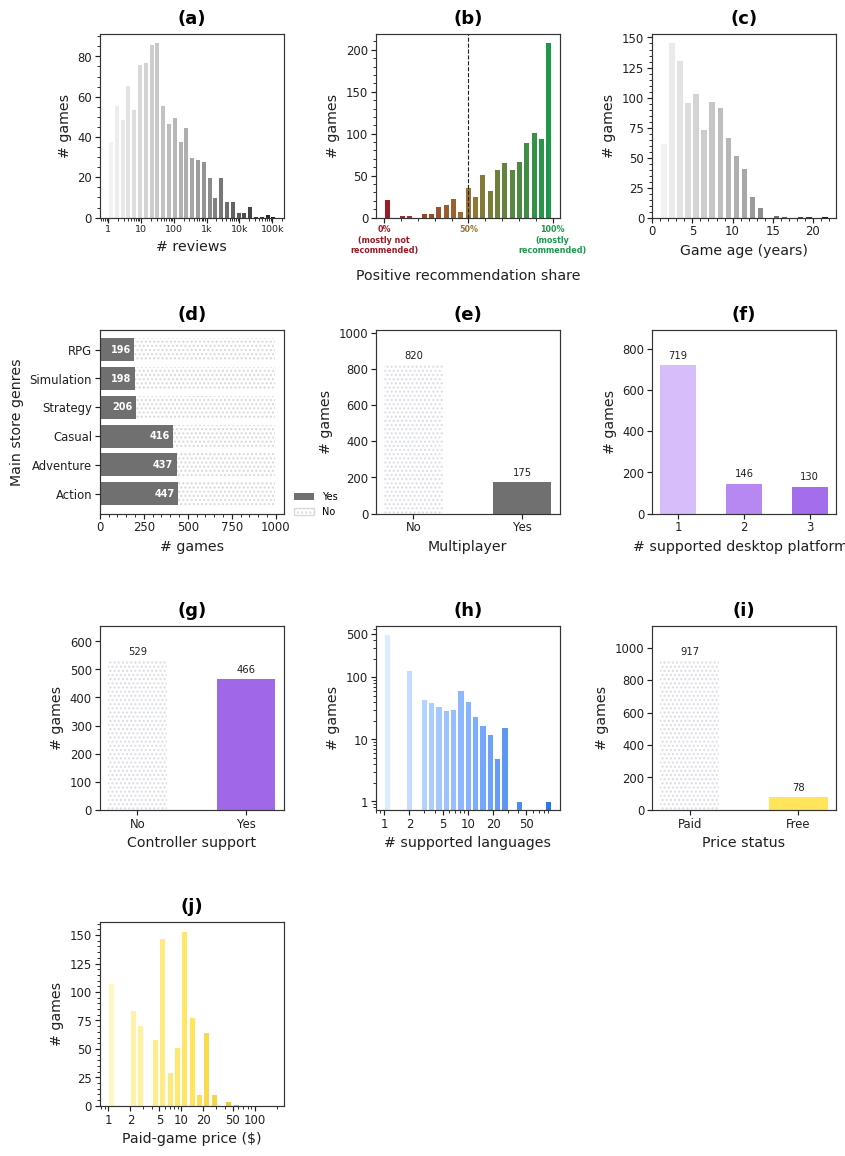

In [311]:
fig, axes = plt.subplots(4, 3, figsize=(9.5, 14))
axes = axes.ravel()
for ax in axes:
    ax.set_box_aspect(1)

total_n = len(df)

# (a) Reviews
reviews = df.loc[df['total_reviews'] > 0, 'total_reviews']
review_ticks_panel = [1, 10, 100, 1000, 10000, 100000]
review_ticks_panel = [x for x in review_ticks_panel if reviews.min() <= x <= reviews.max()]
review_tick_labels_panel = [{1: '1', 10: '10', 100: '100', 1000: '1k', 10000: '10k', 100000: '100k'}[x] for x in review_ticks_panel]
review_bins = np.logspace(np.log10(reviews.min()), np.log10(reviews.max()), 30)

log_gradient_hist(axes[0], reviews, review_bins, review_ticks_panel, review_tick_labels_panel, grey_cmap)
panel_label(axes[0], '(a)')
axes[0].set_xlabel('# reviews')
axes[0].set_ylabel('# games')
clean_axis(axes[0])
axes[0].tick_params(axis='x', labelsize=6.8)

# (b) Positive review rate
positive_bins = np.linspace(0, 1, 24)
gradient_hist(axes[1], df['positive_rate'], positive_bins, review_cmap, Normalize(0, 1))
axes[1].axvline(0.5, color=BLACK, linestyle='--', linewidth=0.8)
panel_label(axes[1], '(b)')
axes[1].set_xlabel('Positive recommendation share', labelpad=10)
axes[1].set_ylabel('# games')
color_review_ticks(axes[1])
clean_axis(axes[1])

# (c) Game age
age_bins = range(int(df['game_age_years'].min()), int(df['game_age_years'].max()) + 2)
gradient_hist(axes[2], df['game_age_years'], age_bins, grey_cmap)
panel_label(axes[2], '(c)')
axes[2].set_xlabel('Game age (years)')
axes[2].set_ylabel('# games')
clean_axis(axes[2])

# (d) Genres
genres = pd.Series({
    'Action': df['genre_action'].sum(),
    'Adventure': df['genre_adventure'].sum(),
    'Casual': df['genre_casual'].sum(),
    'Strategy': df['genre_strategy'].sum(),
    'Simulation': df['genre_simulation'].sum(),
    'RPG': df['genre_rpg'].sum(),
}).sort_values(ascending=False)

shaded_barh(axes[3], genres, DARK_GREY, total_n)
panel_label(axes[3], '(d)')
axes[3].set_xlabel('# games')
axes[3].set_ylabel('Main store genres')
clean_axis(axes[3], minor_x=True, minor_y=False)

# (e) Multiplayer
multi_counts = plot_df['has_multiplayer'].value_counts().reindex([0, 1], fill_value=0).values
binary_bar(axes[4], ['No', 'Yes'], multi_counts, 1, DARK_GREY)
panel_label(axes[4], '(e)')
axes[4].set_xlabel('Multiplayer')
axes[4].set_ylabel('# games')
clean_axis(axes[4], minor_x=False, minor_y=False)

# (f) Supported desktop platform count
platform_count_plot = df['platform_count'].value_counts().reindex([1, 2, 3], fill_value=0)
count_bar(
    axes[5],
    platform_count_plot.index.astype(str),
    platform_count_plot.values,
    purple_cmap([0.20, 0.58, 0.92])
)
panel_label(axes[5], '(f)')
axes[5].set_xlabel('# supported desktop platforms')
axes[5].set_ylabel('# games')
clean_axis(axes[5], minor_x=False, minor_y=False)

# (g) Controller support
controller_counts = plot_df['has_controller_support'].value_counts().reindex([0, 1], fill_value=0).values
binary_bar(axes[6], ['No', 'Yes'], controller_counts, 1, TECH_PURPLE)
panel_label(axes[6], '(g)')
axes[6].set_xlabel('Controller support')
axes[6].set_ylabel('# games')
clean_axis(axes[6], minor_x=False, minor_y=False)

# (h) Supported language count
language_counts = df.loc[df['language_count'] > 0, 'language_count']
lang_ticks = [1, 2, 5, 10, 20, 50]
lang_ticks = [x for x in lang_ticks if language_counts.min() <= x <= language_counts.max()]
lang_bins = np.logspace(np.log10(language_counts.min()), np.log10(language_counts.max()), 24)

log_gradient_hist(axes[7], language_counts, lang_bins, lang_ticks, [str(x) for x in lang_ticks], blue_cmap)
axes[7].set_yscale('log')
axes[7].set_yticks([1, 10, 100, 500])
axes[7].set_yticklabels(['1', '10', '100', '500'])
panel_label(axes[7], '(h)')
axes[7].set_xlabel('# supported languages')
axes[7].set_ylabel('# games')
clean_axis(axes[7])

# (i) Price status
price_counts = plot_df['price_status'].value_counts().reindex(['Paid', 'Free'])
binary_bar(axes[8], price_counts.index, price_counts.values, 1, ECON_YELLOW)
panel_label(axes[8], '(i)')
axes[8].set_xlabel('Price status')
axes[8].set_ylabel('# games')
clean_axis(axes[8], minor_x=False, minor_y=False)

# (j) Paid-game price
paid_price = df.loc[(df['is_free'] == 0) & (df['initial_price_numeric'] > 0), 'initial_price_numeric']
price_ticks = [1, 2, 5, 10, 20, 50, 100]
price_ticks = [x for x in price_ticks if paid_price.min() <= x <= paid_price.max()]
price_bins = np.logspace(np.log10(paid_price.min()), np.log10(paid_price.max()), 24)

log_gradient_hist(axes[9], paid_price, price_bins, price_ticks, [str(x) for x in price_ticks], yellow_cmap)
panel_label(axes[9], '(j)')
axes[9].set_xlabel('Paid-game price ($)')
axes[9].set_ylabel('# games')
clean_axis(axes[9])

# Empty remaining axes
axes[10].axis('off')
axes[11].axis('off')

fig.subplots_adjust(wspace=0.5, hspace=0.56)
show_figure(fig)

## 7. Data Modeling

### **Model Equation**

The dependent variable is not standardized. Only almost continuous predictors are standardized; binary indicators remain coded 0/1.

$$
\begin{aligned}
\log(\mathrm{Number\ of\ reviews}_i) =\;& \beta_0 \\
&+ \beta_{1}\,\mathrm{Positive\ review\ rate}_i
+ \beta_{2}\,\mathrm{Game\ age}_i \\
&+ \beta_{3}\,\mathrm{Action\ genre}_i
+ \beta_{4}\,\mathrm{Adventure\ genre}_i
+ \beta_{5}\,\mathrm{Casual\ genre}_i \\
&+ \beta_{6}\,\mathrm{RPG\ genre}_i
+ \beta_{7}\,\mathrm{Simulation\ genre}_i
+ \beta_{8}\,\mathrm{Strategy\ genre}_i \\
&+ \beta_{9}\,\mathrm{Multiplayer}_i \\
&+ \beta_{10}\,\mathrm{Supported\ desktop\ platform\ count}_i \\
&+ \beta_{11}\,\mathrm{Controller\ support}_i \\
&+ \beta_{12}\,\log(\mathrm{Language\ count}_i) \\
&+ \beta_{13}\,\mathrm{Free\text{-}to\text{-}play}_i
+ \beta_{14}\,\log(\mathrm{Paid\text{-}game\ price}_i) \\
&+ \varepsilon_i
\end{aligned}
$$

### 7.a. Regression Model

In [312]:
model_data = df[['log_total_reviews'] + final_predictors].dropna().copy()
formula = 'log_total_reviews ~ ' + ' + '.join(final_predictors)
main_model = smf.ols(formula, data=model_data).fit(cov_type='HC3')

### 7.b. Coefficient Table

In [313]:
def format_p_value(p):
    if p < 0.001:
        return 'p < 0.001'
    return f'p = {p:.3f}'

coef_table = pd.DataFrame({
    'term': main_model.params.index,
    'estimate': main_model.params.values,
    'robust_se': main_model.bse.values,
    'ci_low': main_model.conf_int()[0].values,
    'ci_high': main_model.conf_int()[1].values,
    'p_value': main_model.pvalues.values,
})
coef_table = coef_table[coef_table['term'] != 'Intercept'].copy()
coef_table['p'] = coef_table['p_value'].apply(format_p_value)
coef_table['estimate'] = coef_table['estimate'].round(3)
coef_table['robust_se'] = coef_table['robust_se'].round(3)
coef_table['ci_low'] = coef_table['ci_low'].round(3)
coef_table['ci_high'] = coef_table['ci_high'].round(3)
display(coef_table[['term', 'estimate', 'robust_se', 'ci_low', 'ci_high', 'p']])

,term,estimate,robust_se,ci_low,ci_high,p
1,is_free,1.450,0.251,0.959,1.942,p < 0.001
2,z_positive_rate,0.223,0.053,0.119,0.328,p < 0.001
3,z_game_age_years,0.728,0.058,0.615,0.841,p < 0.001
4,z_log_price_paid,0.460,0.082,0.298,0.621,p < 0.001
5,z_log_language_count,0.579,0.070,0.442,0.717,p < 0.001
6,z_platform_count,0.154,0.061,0.033,0.274,p = 0.012
7,has_controller_support,0.136,0.128,-0.116,0.388,p = 0.289
8,has_multiplayer,0.715,0.177,0.369,1.061,p < 0.001
9,genre_action,-0.141,0.125,-0.385,0.104,p = 0.260
10,genre_adventure,0.485,0.116,0.257,0.712,p < 0.001


### 7.c. Forest Plot Labels

In [314]:
label_map = {
    'is_free': 'Free-to-play',
    'z_positive_rate': 'Positive review rate',
    'z_game_age_years': 'Game age',
    'z_log_price_paid': 'Log paid-game price',
    'z_log_language_count': 'Log language count',
    'z_platform_count': 'Supported desktop platform count',
    'has_controller_support': 'Controller support',
    'has_multiplayer': 'Multiplayer',
    'genre_action': 'Action genre',
    'genre_adventure': 'Adventure genre',
    'genre_casual': 'Casual genre',
    'genre_rpg': 'RPG genre',
    'genre_simulation': 'Simulation genre',
    'genre_strategy': 'Strategy genre',
}

### 7.d. Forest Plot Data

In [315]:
forest_rows = []
for term in final_predictors:
    ci = main_model.conf_int().loc[term]
    coef = main_model.params[term]
    pvalue = main_model.pvalues[term]
    forest_rows.append({
        'term': term,
        'label': label_map[term],
        'coef': coef,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'pvalue': pvalue,
        'crosses_zero': ci[0] <= 0 <= ci[1],
        'minus_log_p': -np.log10(max(pvalue, 1e-300))
    })
forest = pd.DataFrame(forest_rows)
forest = forest.sort_values(['coef', 'minus_log_p'], ascending=[False, False]).reset_index(drop=True)

### 7.e. Forest Plot

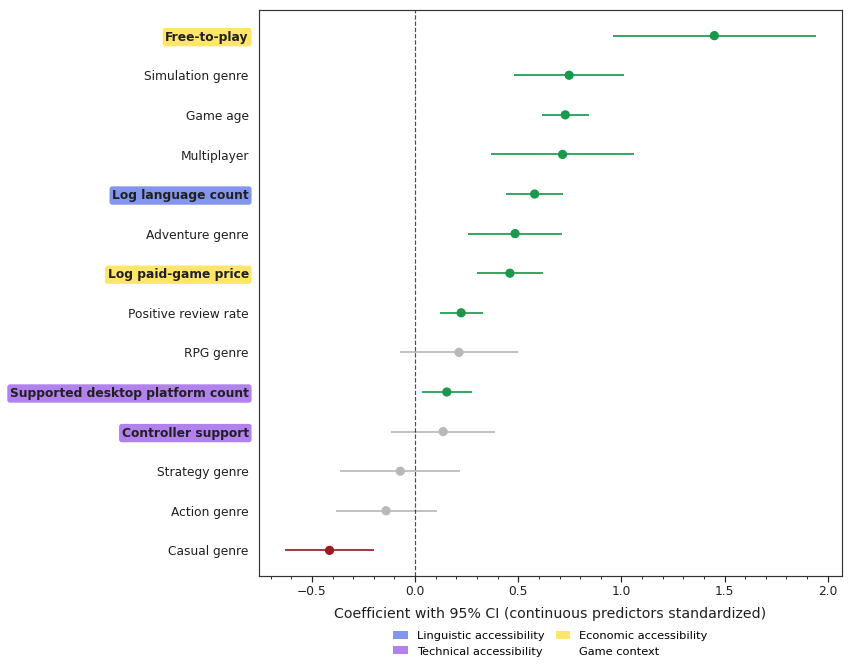

In [316]:
fig, ax = plt.subplots(figsize=(8.6, 7.2))
y = np.arange(len(forest))
colors = np.where(forest['crosses_zero'], MID_GREY, np.where(forest['coef'] > 0, GREEN, RED))
linguistic_terms = ['z_log_language_count']
technical_terms = ['z_platform_count', 'has_controller_support']
economic_terms = ['is_free', 'z_log_price_paid']
highlight_styles = {}
for term in linguistic_terms:
    highlight_styles[term] = {'facecolor': LINGUISTIC_BLUE, 'edgecolor': 'none', 'boxstyle': 'round,pad=0.22', 'alpha': 0.82}
for term in technical_terms:
    highlight_styles[term] = {'facecolor': TECH_PURPLE, 'edgecolor': 'none', 'boxstyle': 'round,pad=0.22', 'alpha': 0.82}
for term in economic_terms:
    highlight_styles[term] = {'facecolor': ECON_YELLOW, 'edgecolor': 'none', 'boxstyle': 'round,pad=0.22', 'alpha': 0.92}

ax.hlines(y, forest['ci_low'], forest['ci_high'], color=colors, linewidth=1.3, alpha=0.95)
ax.scatter(forest['coef'], y, s=32, color=colors, zorder=3)
ax.axvline(0, color=BLACK, linestyle='--', linewidth=0.85, alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(forest['label'])
for i, tick in enumerate(ax.get_yticklabels()):
    term = forest.loc[i, 'term']
    if term in highlight_styles:
        tick.set_fontweight('bold')
        tick.set_color(BLACK)
        tick.set_bbox(highlight_styles[term])
    else:
        tick.set_fontweight('normal')
        tick.set_color(BLACK)
ax.invert_yaxis()
ax.set_xlabel('Coefficient with 95% CI (continuous predictors standardized)', fontsize=10.2, labelpad=7)
ax.set_ylabel('')
ax.grid(False)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='x', which='major', labelsize=8.8, direction='out', length=4, width=0.85, pad=2)
ax.tick_params(axis='x', which='minor', direction='out', length=2, width=0.65, pad=2)
ax.tick_params(axis='y', which='major', labelsize=8.8, length=0, pad=7)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(0.85)
legend_handles = [
    mpl.patches.Patch(facecolor=LINGUISTIC_BLUE, edgecolor='none', alpha=0.82, label='Linguistic accessibility'),
    mpl.patches.Patch(facecolor=TECH_PURPLE, edgecolor='none', alpha=0.82, label='Technical accessibility'),
    mpl.patches.Patch(facecolor=ECON_YELLOW, edgecolor='none', alpha=0.92, label='Economic accessibility'),
    mpl.lines.Line2D([0], [0], color=BLACK, lw=0, label='Game context'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=8.2, handlelength=1.25, columnspacing=1.0)
fig.tight_layout(rect=[0, 0.06, 1, 1])
show_figure(fig)